In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/shivamshinde123/autismprediction/train.csv
/kaggle/input/datasets/shivamshinde123/autismprediction/test.csv


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pickle

print("The libraries are imported!!!!!!!")

The libraries are imported!!!!!!!


In [3]:
dataset = pd.read_csv("/kaggle/input/datasets/shivamshinde123/autismprediction/train.csv")
dataset.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [4]:
dataset.shape

(800, 22)

In [5]:
dataset.isnull().sum()

ID                 0
A1_Score           0
A2_Score           0
A3_Score           0
A4_Score           0
A5_Score           0
A6_Score           0
A7_Score           0
A8_Score           0
A9_Score           0
A10_Score          0
age                0
gender             0
ethnicity          0
jaundice           0
austim             0
contry_of_res      0
used_app_before    0
result             0
age_desc           0
relation           0
Class/ASD          0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [7]:
# convertinf the age float to int
dataset['age'] = dataset['age'].astype(int)
dataset['age'].head()

0    38
1    47
2     7
3    23
4    43
Name: age, dtype: int64

In [8]:
for col in dataset.columns:
    numerical_features = ['ID', 'age', 'result']
    if col not in numerical_features:
        print(col, dataset[col].unique())
        print("-"*50)
        

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender ['f' 'm']
--------------------------------------------------
ethnicity ['?' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Others'
 'Hispanic' 'Asian' 'Turkish' 'South Asian' 'Latino' 'others']
--------------------------------------------------
jaundice ['no' 'yes']
--------------------------------------------------
austim

In [9]:
dataset = dataset.drop(columns=['ID', 'age_desc'])
dataset.shape

(800, 20)

In [10]:
# define the mapping the dictionary for mapping

mapping = {
    "Viet Nam" : "Vietnam",
    "AmericanSamoa" : "United States",
    "Hong Kong" : "China"
}

# replace the values to new values

dataset['contry_of_res '] = dataset['contry_of_res'].replace(mapping)

# find the unique values again

dataset['contry_of_res '].unique()

array(['Austria', 'India', 'United States', 'South Africa', 'Jordan',
       'United Kingdom', 'Brazil', 'New Zealand', 'Canada', 'Kazakhstan',
       'United Arab Emirates', 'Australia', 'Ukraine', 'Iraq', 'France',
       'Malaysia', 'Vietnam', 'Egypt', 'Netherlands', 'Afghanistan',
       'Oman', 'Italy', 'Bahamas', 'Saudi Arabia', 'Ireland', 'Aruba',
       'Sri Lanka', 'Russia', 'Bolivia', 'Azerbaijan', 'Armenia',
       'Serbia', 'Ethiopia', 'Sweden', 'Iceland', 'China', 'Angola',
       'Germany', 'Spain', 'Tonga', 'Pakistan', 'Iran', 'Argentina',
       'Japan', 'Mexico', 'Nicaragua', 'Sierra Leone', 'Czech Republic',
       'Niger', 'Romania', 'Cyprus', 'Belgium', 'Burundi', 'Bangladesh'],
      dtype=object)

In [11]:
# checking for class imbalance

dataset['Class/ASD'].value_counts()

# lot of imbalance

Class/ASD
0    639
1    161
Name: count, dtype: int64

In [12]:
dataset.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


Univariant analysis
    • categorical
    • numerical

The average age of the people: 27.96375
The median age of the people: 24.0


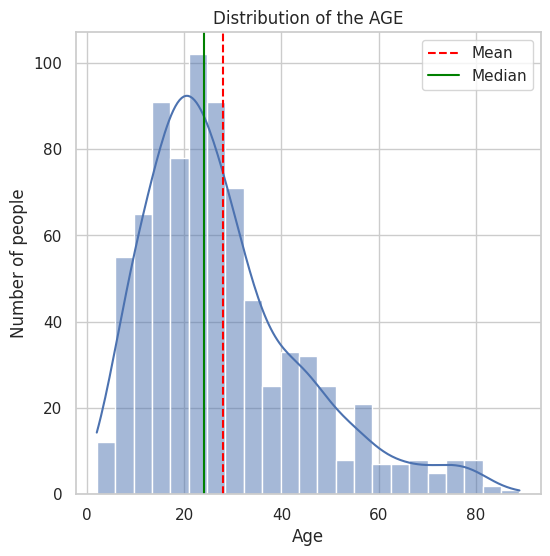

In [13]:
# numerical data {age, result}

sns.set_theme(style='whitegrid')

plt.figure(figsize=(6,6))
sns.histplot(dataset['age'], kde=True)
plt.title("Distribution of the AGE")
plt.xlabel("Age")
plt.ylabel("Number of people")


# calculating the mean and median values for age

mean_age = dataset['age'].mean()
median_age = dataset['age'].median()

print("The average age of the people:", mean_age)
print("The median age of the people:",median_age)

# displaying the mean and median on the plot

plt.axvline(mean_age, linestyle="--", color='red',label='Mean')
plt.axvline(median_age, linestyle="-", color='green',label='Median')
plt.legend()

plt.show()

# As the dataset is right skew mean > median
# if the dataset is left skew mean < median

The average age of the people: 27.96375
The median age of the people: 24.0


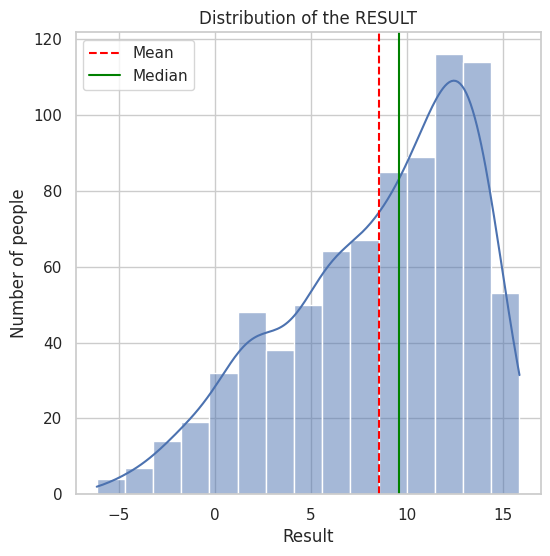

In [14]:
# numerical data {age, result}

sns.set_theme(style='whitegrid')

plt.figure(figsize=(6,6))
sns.histplot(dataset['result'], kde=True)
plt.title("Distribution of the RESULT")
plt.xlabel("Result")
plt.ylabel("Number of people")


# calculating the mean and median values for result

mean_result = dataset['result'].mean()
median_result = dataset['result'].median()

print("The average age of the people:", mean_age)
print("The median age of the people:",median_age)

# displaying the mean and median on the plot

plt.axvline(mean_result, linestyle="--", color='red',label='Mean')
plt.axvline(median_result, linestyle="-", color='green',label='Median')
plt.legend()

plt.show()

# As the dataset is right skew mean > median
# if the dataset is left skew mean < median

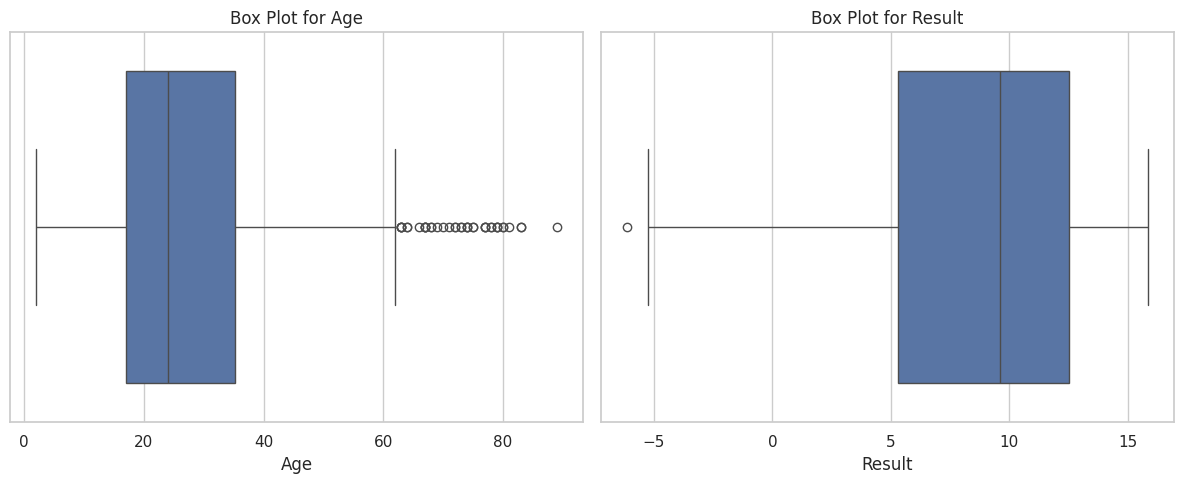

In [15]:
# create subplot layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for age
sns.boxplot(x=dataset['age'], ax=axes[0])
axes[0].set_title("Box Plot for Age")
axes[0].set_xlabel("Age")

# Boxplot for result
sns.boxplot(x=dataset['result'], ax=axes[1])
axes[1].set_title("Box Plot for Result")
axes[1].set_xlabel("Result")

# adjust spacing
plt.tight_layout()

# show plots
plt.show()

In [16]:
q1 = dataset['age'].quantile(0.25)
q3 = dataset['age'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
age_outliers = dataset[(dataset['age'] < lower_bound) | (dataset['age'] > upper_bound)]
print("The number of outliers are:", len(age_outliers))

The number of outliers are: 39


In [17]:
q1 = dataset['result'].quantile(0.25)
q3 = dataset['result'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
age_outliers = dataset[(dataset['result'] < lower_bound) | (dataset['result'] > upper_bound)]
print("The number of outliers are:", len(age_outliers))

The number of outliers are: 1


In [18]:
dataset.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'result', 'relation', 'Class/ASD', 'contry_of_res '],
      dtype='object')

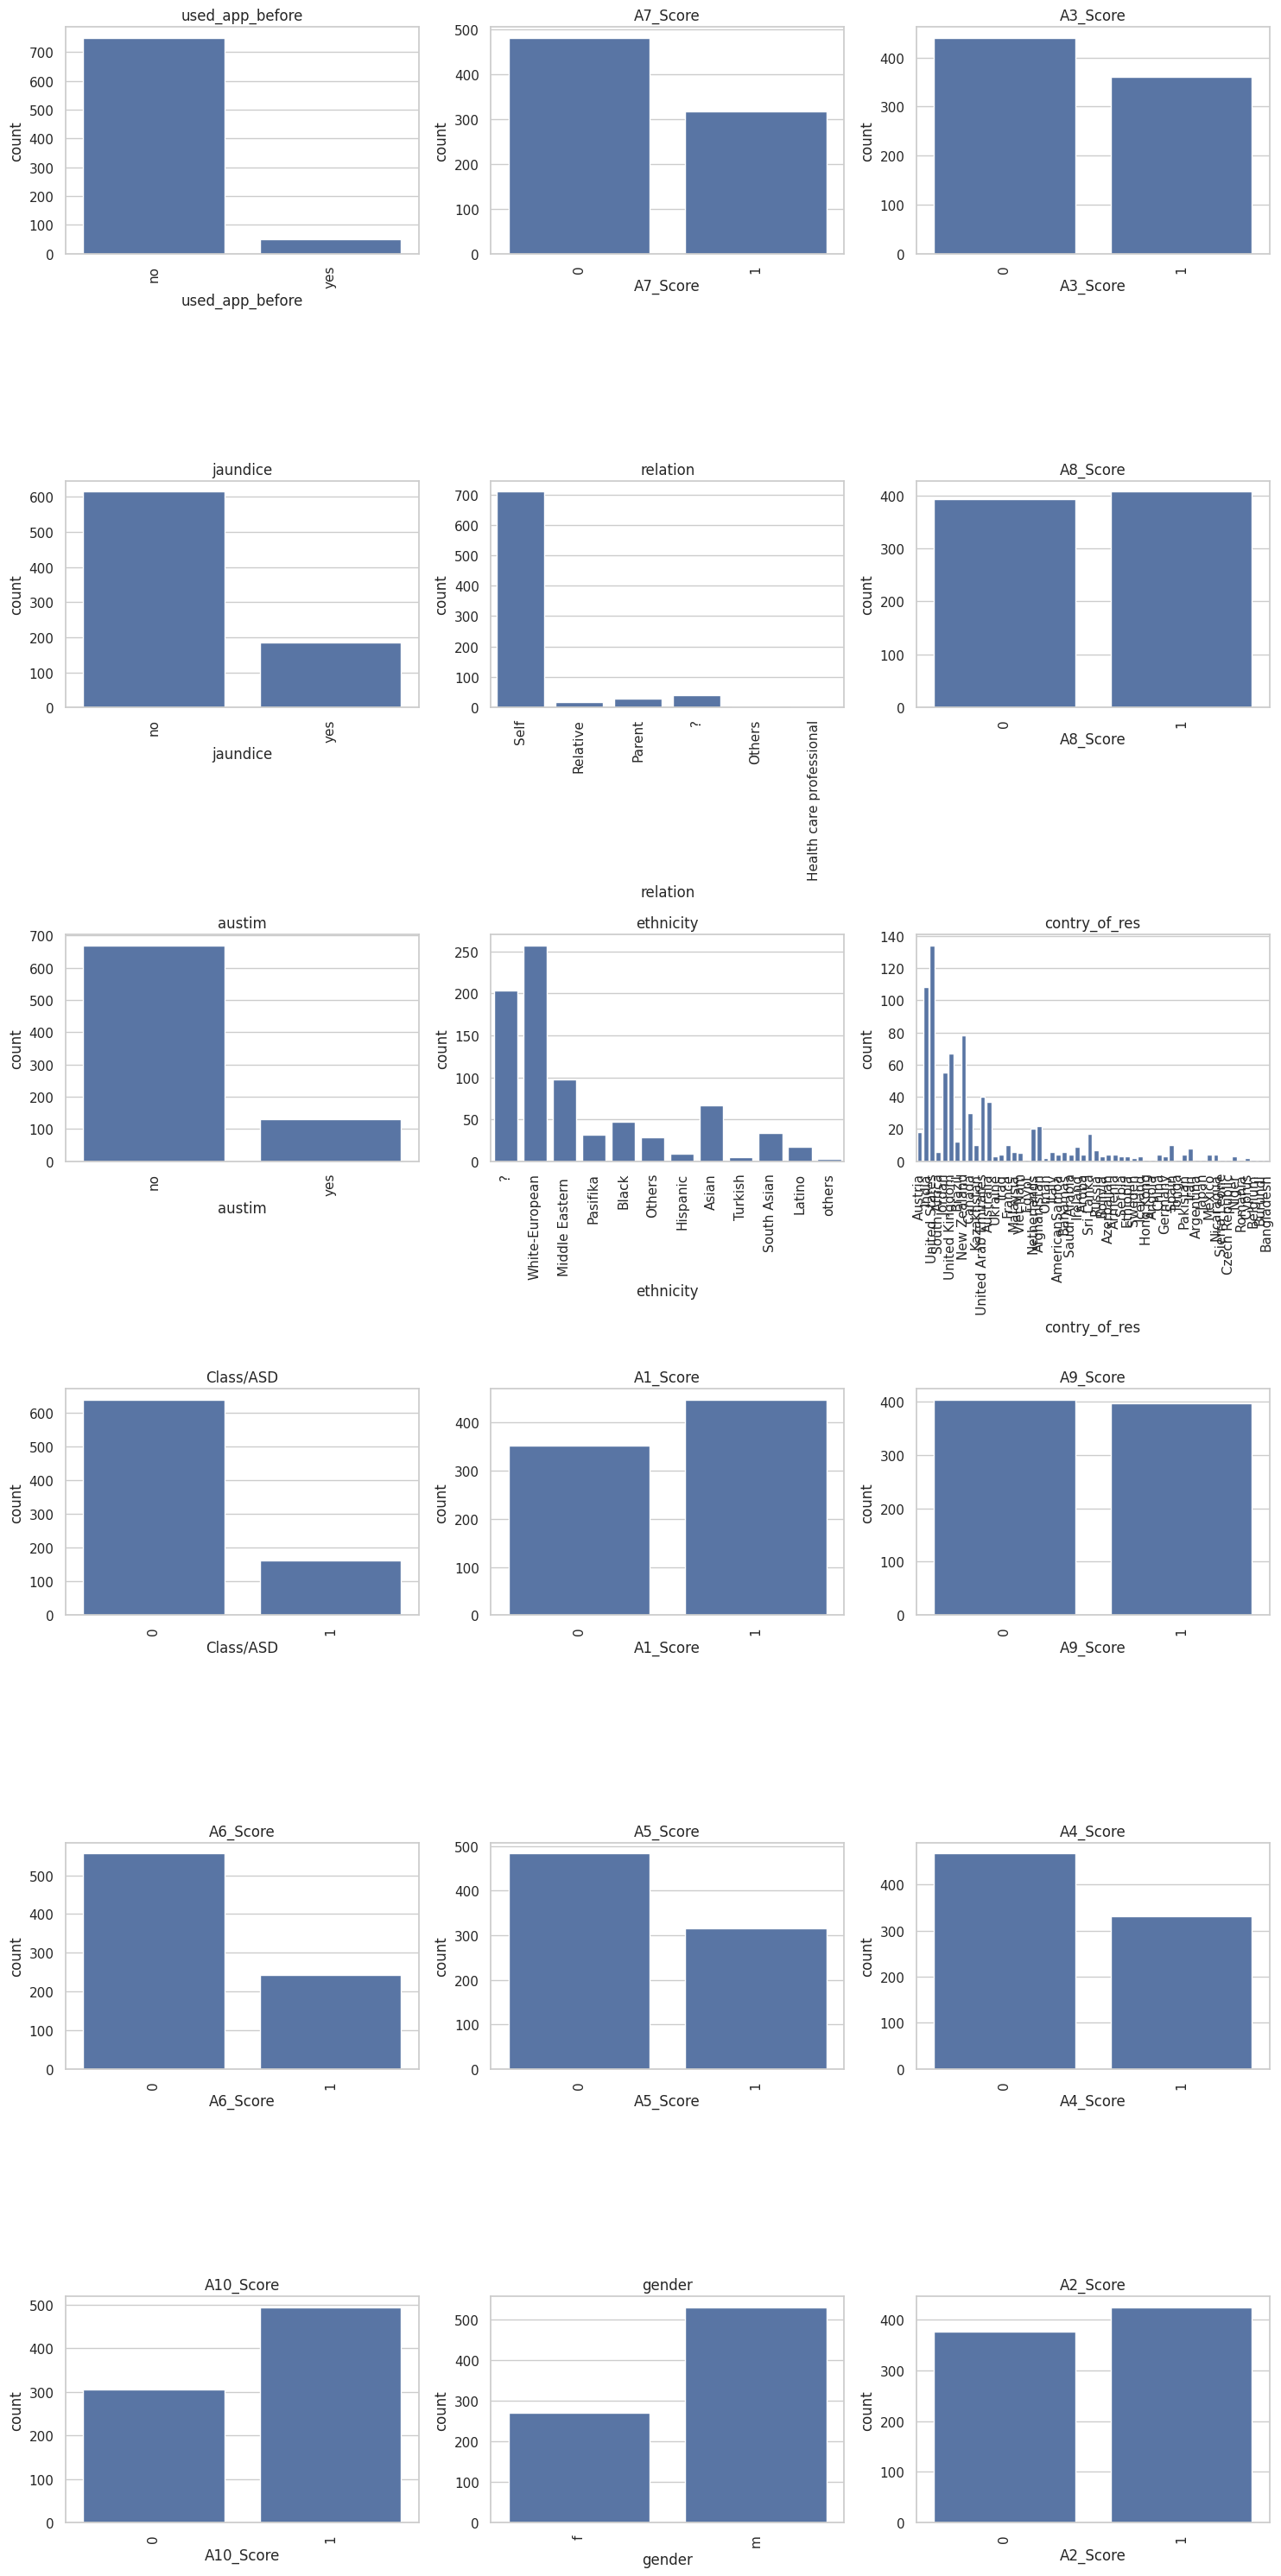

In [19]:
categorical_data = {
    'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
        'relation', 'Class/ASD',
}

cols = 3
rows = math.ceil(len(categorical_data)/cols)
plt.figure(figsize=(15, 5 * rows))
for i, col in enumerate(categorical_data, 1):
    plt.subplot(rows,cols,i)

    sns.countplot(x=dataset[col])
    plt.title(col)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [20]:
dataset['Class/ASD'].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

handling missing values in ethnicity and relation columns

In [21]:
dataset['relation'].unique()

array(['Self', 'Relative', 'Parent', '?', 'Others',
       'Health care professional'], dtype=object)

In [22]:
dataset['ethnicity'].replace({
    "?" : "others",
    "Others" : "others"
}, inplace=True)

dataset['relation'].replace(
    {
        "Relative" : "others",
        "Parent" : "others",
        "?" : "others",
        "Others" : "others",
        "Health care professional" : "others"
    }, inplace=True
)

print(dataset['ethnicity'].unique())
print(dataset['relation'].unique())

['others' 'White-European' 'Middle Eastern ' 'Pasifika' 'Black' 'Hispanic'
 'Asian' 'Turkish' 'South Asian' 'Latino']
['Self' 'others']


/tmp/ipykernel_16/3998692553.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['ethnicity'].replace({
/tmp/ipykernel_16/3998692553.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col:

In [23]:
# obeject cloumns

object_columns = dataset.select_dtypes(include=["object"]).columns

# intialize dictionary for storing the encoders

encoded_dict = { }

for col in object_columns:
    encoder = LabelEncoder()
    dataset[col] = encoder.fit_transform(dataset[col])
    encoded_dict[col] = encoder

with open("encoded_dict.pk", "wb") as f:
    pickle.dump(encoded_dict, f)

Bivariant analysis

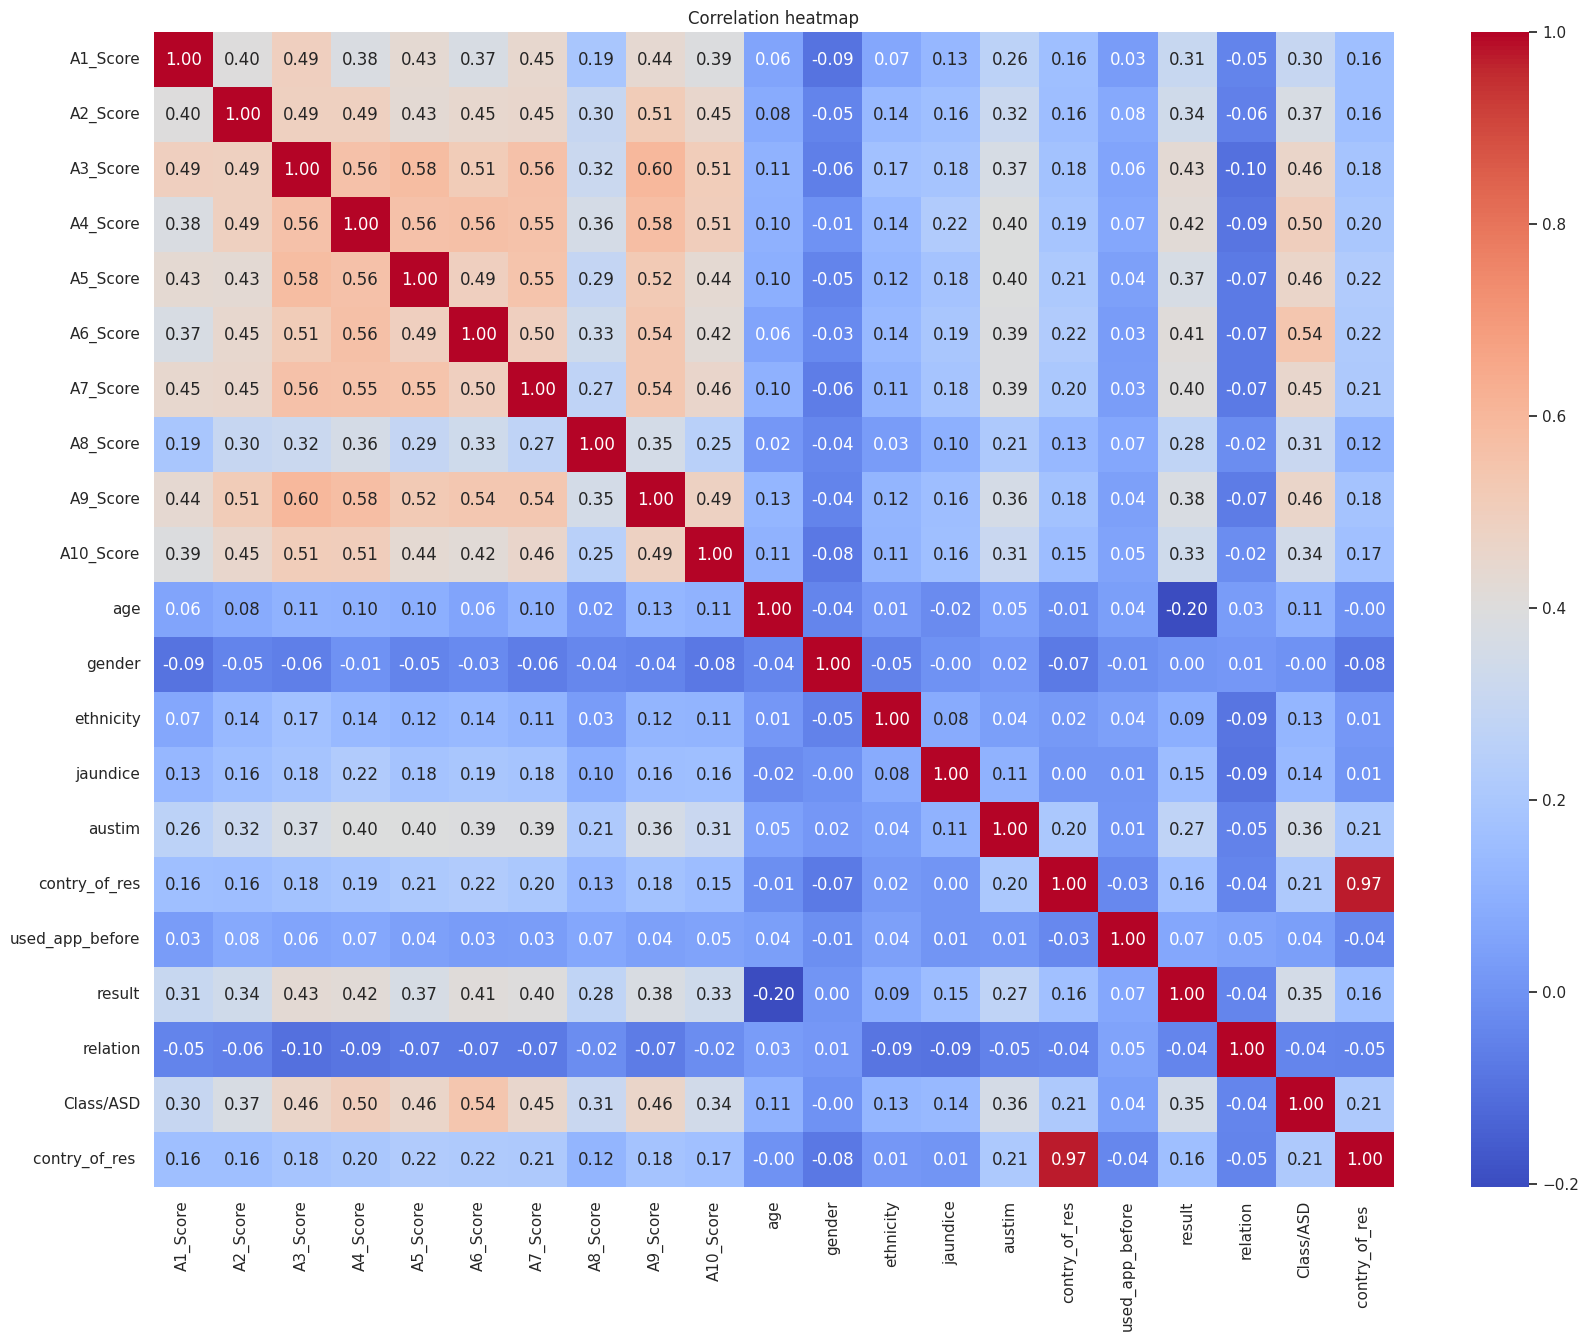

In [24]:
plt.figure(figsize=(20,15))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

Data preprocessing

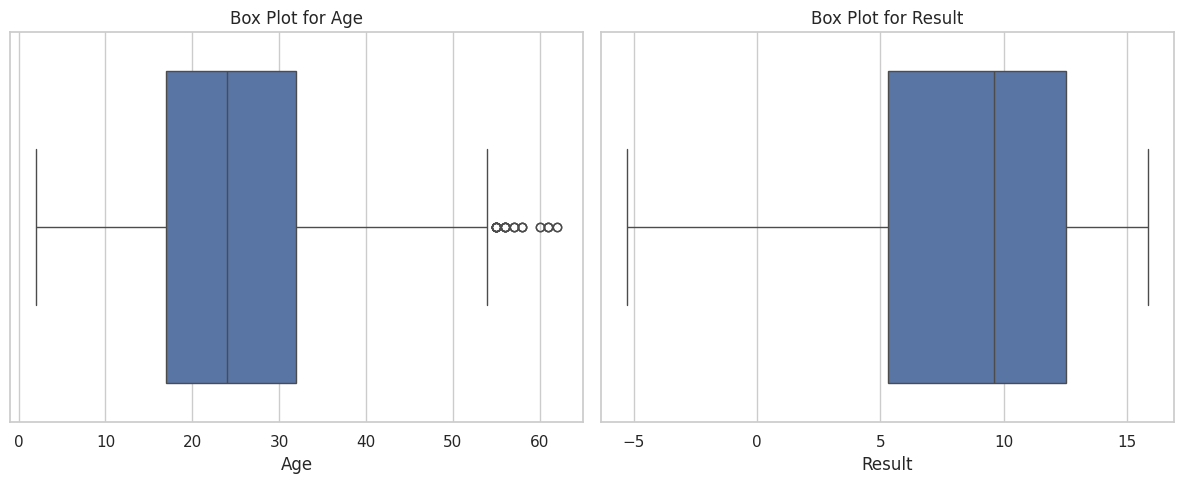

In [25]:
# handling the outliers

def fill_outlier_values_wth_median(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)

    IQR = q3 - q1

    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    median = data[col].median()
    data[col] = data[col].apply(lambda x : median if x < lower_bound or x > upper_bound else x)

    return data

dataset = fill_outlier_values_wth_median(dataset, "age")
dataset = fill_outlier_values_wth_median(dataset, "result")

# create subplot layout (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot for age
sns.boxplot(x=dataset['age'], ax=axes[0])
axes[0].set_title("Box Plot for Age")
axes[0].set_xlabel("Age")

# Boxplot for result
sns.boxplot(x=dataset['result'], ax=axes[1])
axes[1].set_title("Box Plot for Result")
axes[1].set_xlabel("Result")

# adjust spacing
plt.tight_layout()

# show plots
plt.show()


In [26]:
# features and target

x = dataset.drop(columns=['Class/ASD'], axis=1)
y = dataset['Class/ASD']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=.2, random_state=123)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

print(y_train.value_counts())

(640, 20) (160, 20)
(640,) (160,)
Class/ASD
0    511
1    129
Name: count, dtype: int64


In [27]:
# smote 
smote = SMOTE(random_state=123)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print(y_train_smote.value_counts()) # oversampling

Class/ASD
0    511
1    511
Name: count, dtype: int64


In [28]:
# model training
models = {
    "DecisionTree" : DecisionTreeClassifier(random_state=123),
    "RandomForest" : RandomForestClassifier(random_state=123),
    "XGB" : XGBClassifier(random_state=123)
}
print("Models are imported!!")

Models are imported!!


In [29]:
# create dictionary of score
cv_scores = { }

for model_name,model in models.items():
    print(f"training {model_name} with default parameters....")
    scores = cross_val_score(model, x_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross validation accuracy {np.mean(scores):.2f}")
    print("-" * 50)
    


training DecisionTree with default parameters....
DecisionTree cross validation accuracy 0.83
--------------------------------------------------
training RandomForest with default parameters....
RandomForest cross validation accuracy 0.91
--------------------------------------------------
training XGB with default parameters....
XGB cross validation accuracy 0.89
--------------------------------------------------


In [30]:
Decision_tree = DecisionTreeClassifier(random_state=123)
Random_forest = RandomForestClassifier(random_state=123)
XGB_classifier = XGBClassifier(random_state=123)

# hyperparameter tuning

param_grid_dt = {
    "criterion": ["entropy", "gini"],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 4],
    "min_samples_split": [2, 4, 6]
}

param_grid_rf = {
    "n_estimators": [50, 100, 200, 400],
    "max_depth": [4, 7, 10, 20],
    "min_samples_leaf": [1, 2, 3, 4],
    "min_samples_split": [2, 4, 6],
    "bootstrap": [True, False]
}

param_grid_xgb = {
    "n_estimators": [50, 100, 200, 400],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.1, 0.01, 0.2, 0.3],
    "subsample": [0.2, 0.55, 0.75, 1.0],
    "colsample_bytree": [0.5, 0.6, 0.7]
}

print("Models are set!!!")

Models are set!!!


In [31]:
# hyperparameter tuning for each model
# performing the RandomizedSearchCV

# Decision Tree
random_search_dt = RandomizedSearchCV(
    estimator=Decision_tree,
    param_distributions=param_grid_dt,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=32,
    n_jobs=-1
)

# Random Forest
random_search_rf = RandomizedSearchCV(
    estimator=Random_forest,
    param_distributions=param_grid_rf,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=32,
    n_jobs=-1
)

# XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=XGB_classifier,
    param_distributions=param_grid_xgb,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=32,
    n_jobs=-1
)

# fitting models
random_search_dt.fit(x_train_smote, y_train_smote)

random_search_rf.fit(x_train_smote, y_train_smote)

random_search_xgb.fit(x_train_smote, y_train_smote)


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.5, 0.6, 0.7],
                                        'learning_rate': [0.1, 0.01, 0.2, 0.3],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [50, 100, 200, 400],
                                        'subsample': [0.2, 0.55, 0.75, 1.0]},
                   random_state=32, scoring='accuracy')

In [32]:
best_model = None
best_score = 0

if random_search_dt.best_score_ > best_score:
    best_model = random_search_dt.best_estimator_
    best_score = random_search_dt.best_score_
if random_search_rf.best_score_ > best_score:
    best_model = random_search_rf.best_estimator_
    best_score = random_search_rf.best_score_
if random_search_dt.best_score_ > best_score:
    best_model = random_search_xgb.best_estimator_
    best_score = random_search_xgb.best_score_

print(f"the best model is{best_model}")
print(f"The best cross validation score is {best_score}")

the best model isRandomForestClassifier(bootstrap=False, max_depth=10, n_estimators=50,
                       random_state=123)
The best cross validation score is 0.9100000000000001
